# CASAS Smart-Home Activity Dataset: Exploratory Data Analysis
**DA331 Big Data Analytics, Assignment 5 (Task 1)**
**Kumar Utkarsh (240150016)**

Dataset: CASAS smart home `hh101` ([Zenodo 15708568](https://zenodo.org/records/15708568)), Kaggle mirror.

| File | Content |
|---|---|
| `data/hh101.csv` | raw sensor stream: `date time sensor message` (no labels, about one year) |
| `labeled/hh101.csv` | annotated subset: `date,time,sensor,message[,Activity="begin"/"end"]` |

Sensors are ceiling PIR motion sensors (`ON/OFF`) and magnetic door sensors (`OPEN/CLOSE`). The
sensor IDs in the files are already mapped to rooms (Bedroom, Kitchen, ...).

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 30)

BASE = Path("/kaggle/input") if Path("/kaggle/input").exists() else Path("data")
RAW = next(BASE.rglob("data/hh101.csv"))
LAB = next(BASE.rglob("labeled/hh101.csv"))
FIG = Path("figures"); FIG.mkdir(exist_ok=True)
print(RAW, f"{RAW.stat().st_size/1e6:.1f} MB")
print(LAB, f"{LAB.stat().st_size/1e6:.1f} MB")

data/CASAS-hh101/data/hh101.csv 51.3 MB
data/CASAS-hh101/labeled/hh101.csv 9.0 MB


## 1. Loading

In the labelled file, activities are given as `Name="begin"` ... `Name="end"`. A few events next to a
segment carry only the bare name. Every event between a begin and its end gets that activity, a bare name
labels only its own event, and all remaining events are `Other`.

In [2]:
def load_raw(path):
    df = pd.read_csv(path, sep=" ", header=None, names=["date", "time", "sensor", "message"])
    df["timestamp"] = pd.to_datetime(df["date"] + " " + df["time"], format="ISO8601")
    return df[["timestamp", "sensor", "message"]].astype({"sensor": "category", "message": "category"})


def load_labeled(path):
    df = pd.read_csv(path, header=None, names=["date", "time", "sensor", "message", "label"])
    df["timestamp"] = pd.to_datetime(df["date"] + " " + df["time"], format="ISO8601")
    m = df["label"].str.extract(r'^(\w+)(?:="(begin|end)")?$')
    name, mark = m[0], m[1]
    state = pd.Series(np.select([mark.eq("begin"), mark.eq("end")], [name, "<end>"], ""), index=df.index)
    state = state.replace("", np.nan).ffill()
    inside = state.notna() & state.ne("<end>")
    df["activity"] = np.where(mark.eq("end"), name, np.where(inside, state, name.fillna("Other")))
    df = df.sort_values("timestamp", kind="stable").reset_index(drop=True)
    return df[["timestamp", "sensor", "message", "activity"]].astype(
        {"sensor": "category", "message": "category", "activity": "category"})


raw = load_raw(RAW)
lab = load_labeled(LAB)
print("raw:", raw.shape, "| labeled:", lab.shape)
display(raw.head())
display(lab.head())

raw: (1286244, 3) | labeled: (222858, 4)


,timestamp,sensor,message
0,2012-07-18 12:54:45.196564,OutsideDoor,OPEN
1,2012-07-18 12:54:45.682577,Kitchen,OFF
2,2012-07-18 12:54:45.723461,Bathroom,OPEN
3,2012-07-18 12:54:45.767498,Bedroom,ON
4,2012-07-18 12:54:45.951482,LivingRoom,ON


,timestamp,sensor,message,activity
0,2012-07-20 10:38:54.512364,OutsideDoor,ON,Step_Out
1,2012-07-20 10:38:59.541365,OutsideDoor,OFF,Step_Out
2,2012-07-20 10:39:02.429671,OutsideDoor,ON,Step_Out
3,2012-07-20 10:39:04.120443,OutsideDoor,OFF,Step_Out
4,2012-07-20 10:39:36.167078,OutsideDoor,ON,Step_Out


In [3]:
for name, df in [("raw", raw), ("labeled", lab)]:
    print(f"{name:8s} {df.timestamp.min()} -> {df.timestamp.max()}  "
          f"({(df.timestamp.max() - df.timestamp.min()).days} days), "
          f"memory {df.memory_usage(deep=True).sum()/1e6:.1f} MB")
raw.dtypes

raw      2012-07-18 12:54:45.196564 -> 2013-07-25 11:55:36.480202  (371 days), memory 12.9 MB
labeled  2012-07-20 10:38:54.512364 -> 2012-09-17 23:53:15.887888  (59 days), memory 2.5 MB


timestamp    datetime64[us]
sensor             category
message            category
dtype: object

## 2. Data quality

In [4]:
def quality(df):
    return pd.Series({
        "rows": len(df),
        "missing values": int(df.isna().sum().sum()),
        "duplicate rows": int(df.duplicated().sum()),
        "out-of-order timestamps": int((df.timestamp.diff().dt.total_seconds() < 0).sum()),
        "same-timestamp events": int(df.timestamp.duplicated().sum()),
    })

pd.DataFrame({"raw": quality(raw), "labeled": quality(lab)})

,raw,labeled
rows,1286244,222858
missing values,0,0
duplicate rows,0,0
out-of-order timestamps,0,0
same-timestamp events,0,0


In [5]:
days = raw.set_index("timestamp").resample("D").size()
print("days in range:", len(days), "| days with no events:", int((days == 0).sum()))
gaps = raw.timestamp.diff()
print("longest gaps between events:")
top = gaps.nlargest(5)
pd.DataFrame({"gap": top.values, "after": raw.timestamp[top.index - 1].values})

days in range: 373 | days with no events: 2
longest gaps between events:


,gap,after
0,1 days 23:14:08.808359,2013-07-07 05:35:23.520851
1,1 days 21:24:01.853099,2012-07-18 12:57:33.534186
2,0 days 21:23:49.228650,2013-07-04 21:57:48.514598
3,0 days 14:58:53.044727,2013-07-04 06:58:54.361715
4,0 days 13:00:44.618957,2013-07-06 07:44:14.176887


## 3. Sensors and messages

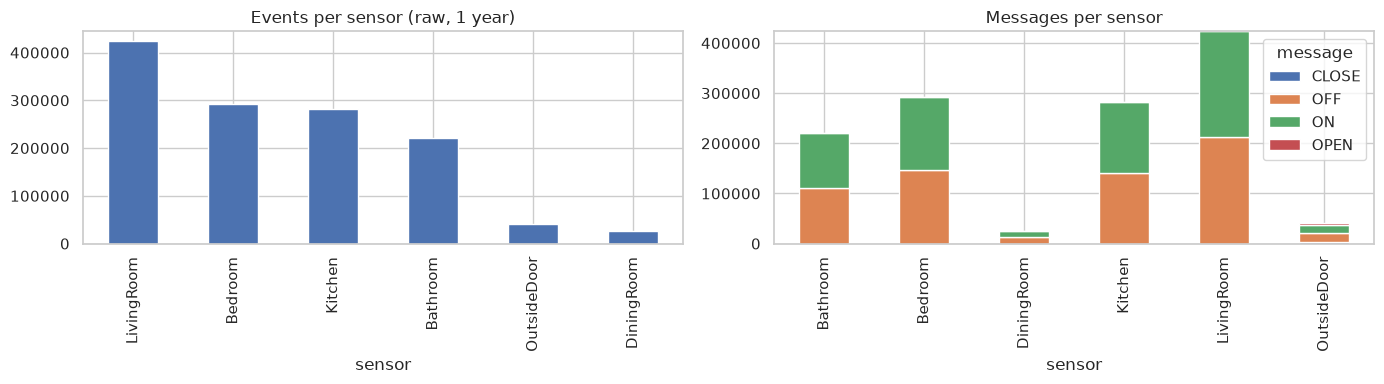

message,CLOSE,OFF,ON,OPEN,All
sensor,,,,,
Bathroom,0,110759,110754,1,221514
Bedroom,0,146076,146066,0,292142
DiningRoom,0,12670,12668,0,25338
Kitchen,0,141263,141253,0,282516
LivingRoom,0,211660,211653,0,423313
OutsideDoor,3586,17124,17123,3588,41421
All,3586,639552,639517,3589,1286244


In [6]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
raw.sensor.value_counts().plot.bar(ax=ax[0], color="C0", title="Events per sensor (raw, 1 year)")
pd.crosstab(raw.sensor, raw.message).plot.bar(stacked=True, ax=ax[1], title="Messages per sensor")
plt.tight_layout(); plt.show()
pd.crosstab(raw.sensor, raw.message, margins=True)

In [7]:
on = raw[raw.message.isin(["ON", "OFF"])].copy()
on["next_ts"] = on.groupby("sensor", observed=True).timestamp.shift(-1)
on["next_msg"] = on.groupby("sensor", observed=True).message.shift(-1)
fire = on[(on.message == "ON") & (on.next_msg == "OFF")]
fire_s = (fire.next_ts - fire.timestamp).dt.total_seconds()
fire_s.groupby(fire.sensor, observed=True).describe(percentiles=[.5, .9])[["count", "50%", "90%", "max"]].round(1)

,count,50%,90%,max
sensor,,,,
Bathroom,110754.0,1.7,5.1,410.5
Bedroom,117196.0,1.1,3.0,551.2
DiningRoom,12668.0,1.2,2.8,124.6
Kitchen,103369.0,1.1,3.5,82.1
LivingRoom,190362.0,1.1,2.3,30.3
OutsideDoor,17123.0,1.8,5.3,167.1


## 4. Temporal patterns (raw stream)

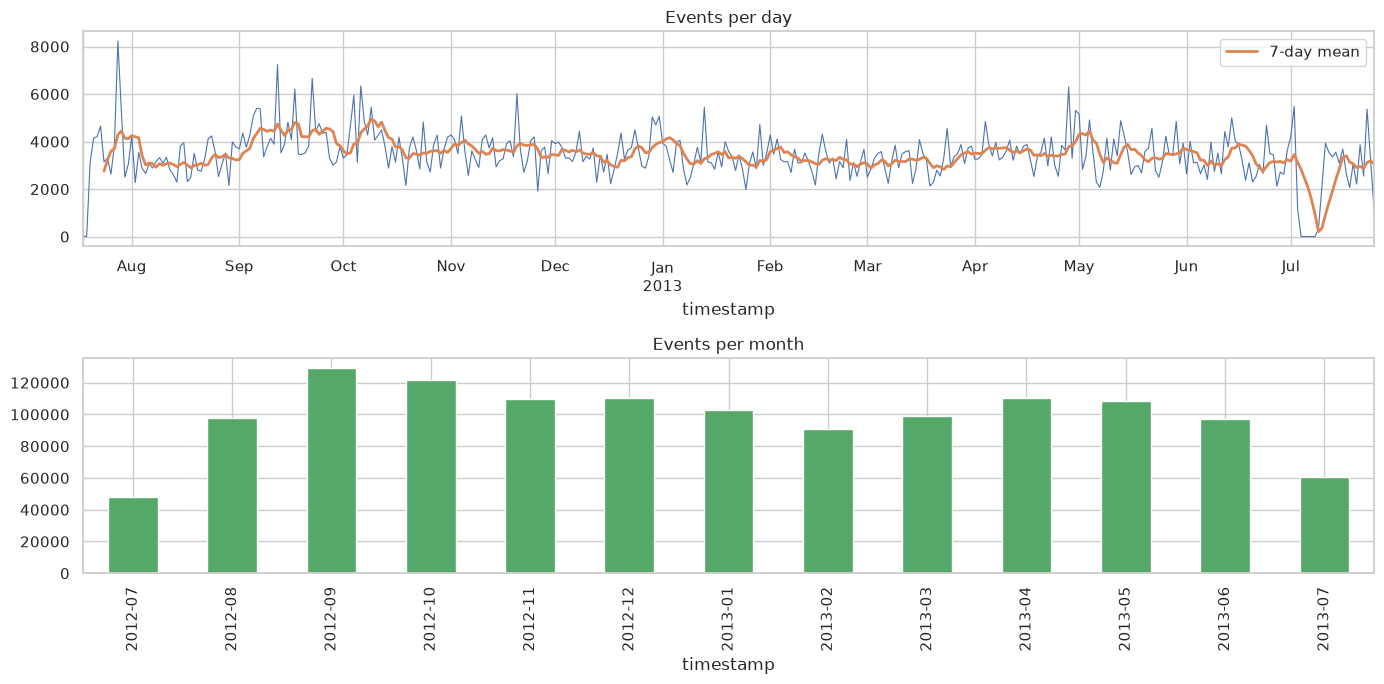

In [8]:
fig, ax = plt.subplots(2, 1, figsize=(14, 7))
days.plot(ax=ax[0], lw=.8, title="Events per day")
days.rolling(7).mean().plot(ax=ax[0], lw=2, label="7-day mean"); ax[0].legend()
raw.groupby(raw.timestamp.dt.to_period("M")).size().plot.bar(ax=ax[1], color="C2", title="Events per month")
plt.tight_layout(); plt.savefig(FIG / "eda_daily.png", dpi=110); plt.show()

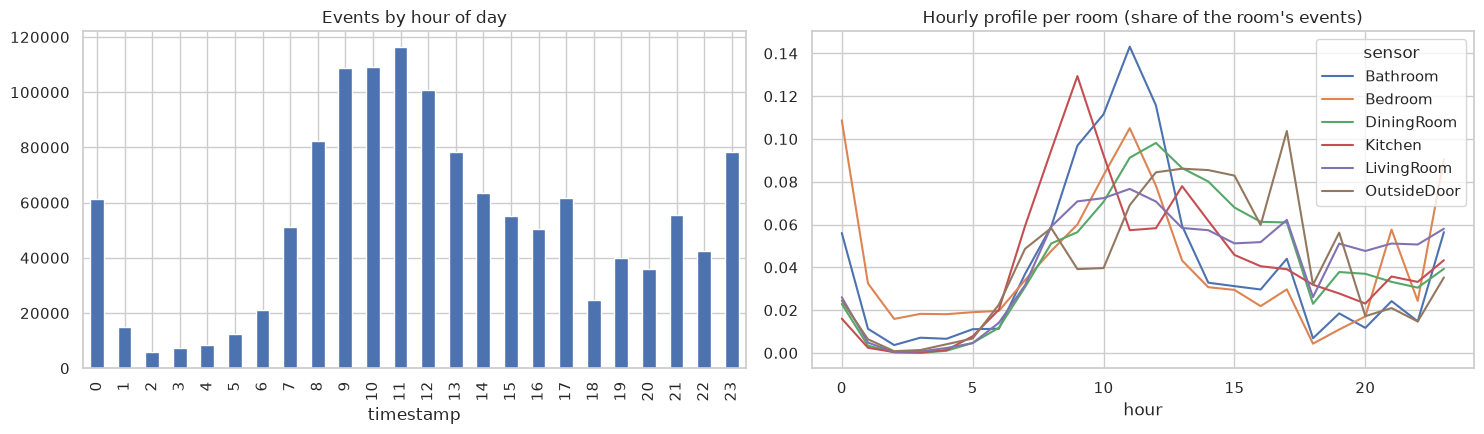

In [9]:
hour_room = pd.crosstab(raw.timestamp.dt.hour, raw.sensor, normalize="columns")
fig, ax = plt.subplots(1, 2, figsize=(15, 4.5))
raw.timestamp.dt.hour.value_counts().sort_index().plot.bar(ax=ax[0], color="C0", title="Events by hour of day")
hour_room.plot(ax=ax[1], title="Hourly profile per room (share of the room's events)")
ax[1].set_xlabel("hour"); plt.tight_layout(); plt.show()

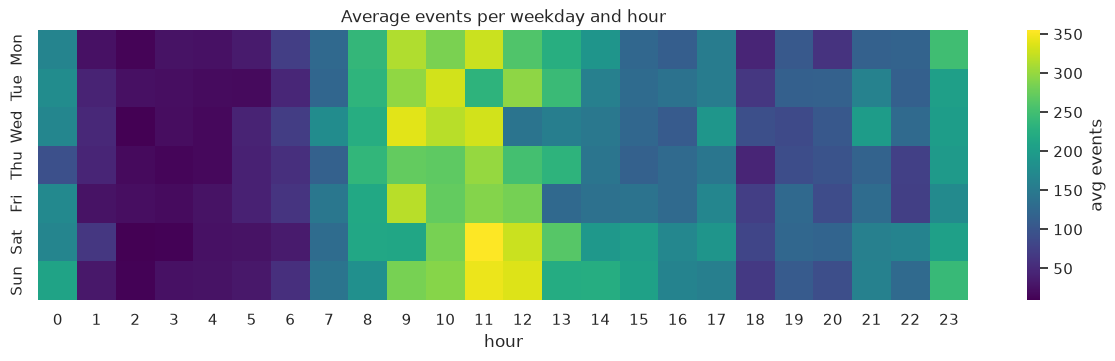

In [10]:
wd = pd.crosstab(raw.timestamp.dt.day_name().str[:3], raw.timestamp.dt.hour)
wd = wd.reindex(["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]) / days.groupby(days.index.dayofweek).size().values[:, None]
plt.figure(figsize=(15, 3.5))
sns.heatmap(wd, cmap="viridis", cbar_kws={"label": "avg events"})
plt.title("Average events per weekday and hour"); plt.xlabel("hour"); plt.ylabel(""); plt.show()

count    1286243.00
mean          24.99
std          349.72
min            0.02
50%            1.17
90%           12.42
99%          341.45
max       170048.81
Name: timestamp, dtype: float64


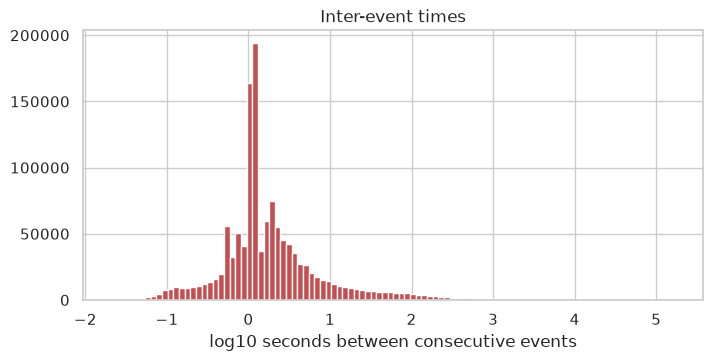

In [11]:
dt = raw.timestamp.diff().dt.total_seconds().dropna()
print(dt.describe(percentiles=[.5, .9, .99]).round(2))
plt.figure(figsize=(8, 3.5))
plt.hist(np.log10(dt.clip(lower=1e-3)), bins=100, color="C3")
plt.xlabel("log10 seconds between consecutive events"); plt.title("Inter-event times"); plt.show()

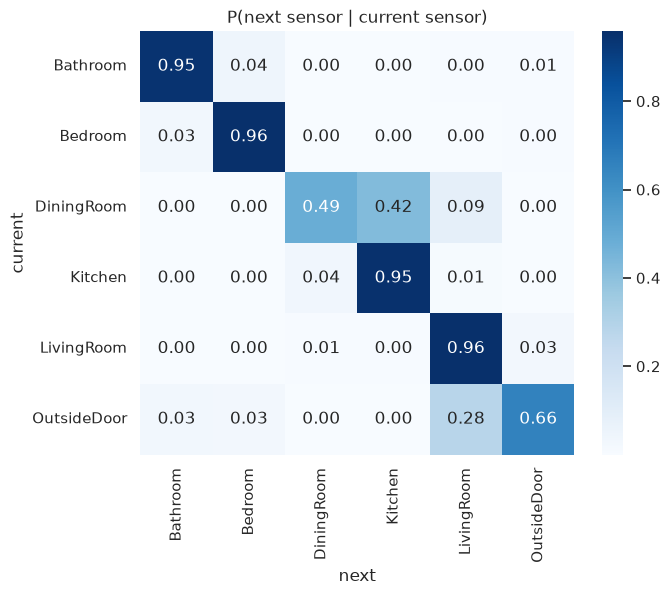

In [12]:
room_seq = raw.sensor.astype(str)
moves = pd.crosstab(room_seq, room_seq.shift(-1), normalize="index")
plt.figure(figsize=(7, 5.5))
sns.heatmap(moves, annot=True, fmt=".2f", cmap="Blues")
plt.title("P(next sensor | current sensor)"); plt.xlabel("next"); plt.ylabel("current"); plt.show()

## 5. Activities (labelled subset)

activity labels (excluding Other): 34
share of events labelled Other: 27.9%


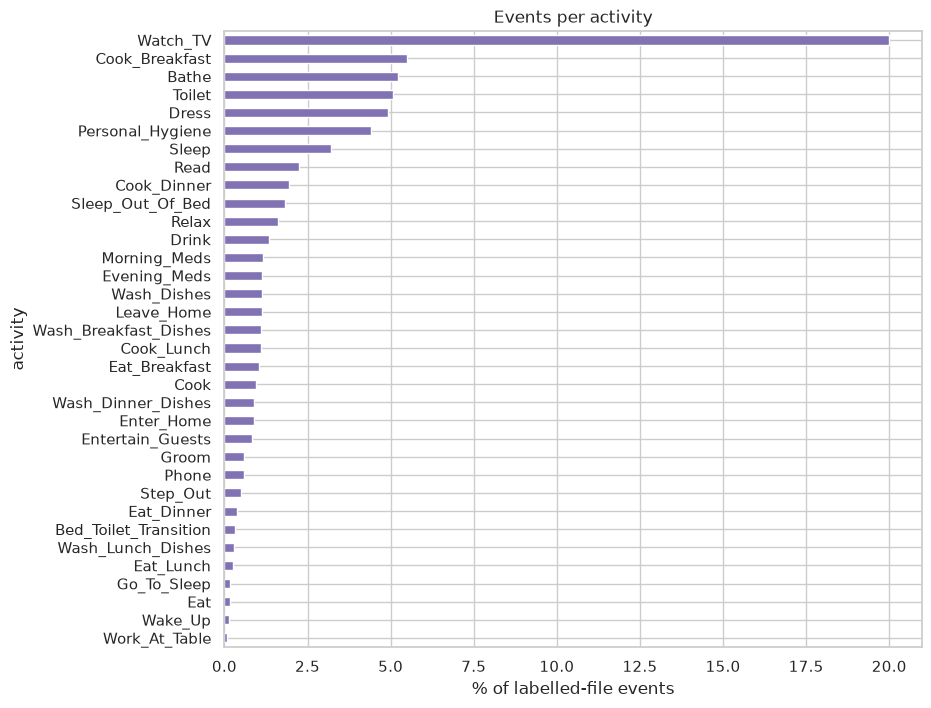

In [13]:
ev = lab.activity.value_counts()
print("activity labels (excluding Other):", lab.activity.nunique() - 1)
print(f"share of events labelled Other: {ev['Other'] / len(lab):.1%}")
plt.figure(figsize=(9, 8))
(ev.drop("Other") / len(lab) * 100).sort_values().plot.barh(color="C4")
plt.xlabel("% of labelled-file events"); plt.title("Events per activity"); plt.show()

One activity instance produces many events, so event counts overweight long activities.
Below, each annotated segment (a run of consecutive events with the same label) becomes an
**episode**. `Other` runs are dropped, and same-label fragments less than 1 minute apart are merged. The model notebook uses the same episodes.

In [14]:
def build_episodes(df, merge_gap_min=1):
    a = df.activity.astype(str)
    run = (a != a.shift()).cumsum()
    ep = df.assign(activity=a).groupby(run).agg(
        activity=("activity", "first"), start=("timestamp", "first"), end=("timestamp", "last"),
        n_events=("timestamp", "size"), last_sensor=("sensor", "last"))
    ep = ep[ep.activity != "Other"].reset_index(drop=True)
    gap = (ep.start - ep.end.shift()).dt.total_seconds() / 60
    new = (ep.activity != ep.activity.shift()) | (gap > merge_gap_min)
    ep = ep.groupby(new.cumsum()).agg(
        activity=("activity", "first"), start=("start", "first"), end=("end", "last"),
        n_events=("n_events", "sum"), last_sensor=("last_sensor", "last"))
    ep["duration_min"] = (ep.end - ep.start).dt.total_seconds() / 60
    return ep.reset_index(drop=True)

ep = build_episodes(lab)
stats = ep.groupby("activity").agg(episodes=("activity", "size"), median_min=("duration_min", "median"),
                                   total_hours=("duration_min", lambda s: s.sum() / 60),
                                   median_events=("n_events", "median"))
print(len(ep), "episodes")
stats.sort_values("episodes", ascending=False).round(1)

2677 episodes


,episodes,median_min,total_hours,median_events
activity,,,,
Toilet,360,2.4,14.7,32.0
Watch_TV,319,57.2,376.8,88.0
Sleep_Out_Of_Bed,198,58.5,253.8,16.0
Personal_Hygiene,178,4.4,15.3,48.0
Dress,175,3.6,12.4,52.0
Leave_Home,171,0.3,0.9,14.0
Enter_Home,170,0.3,0.8,12.0
Read,87,24.4,47.6,46.0
Relax,75,18.8,27.8,28.0


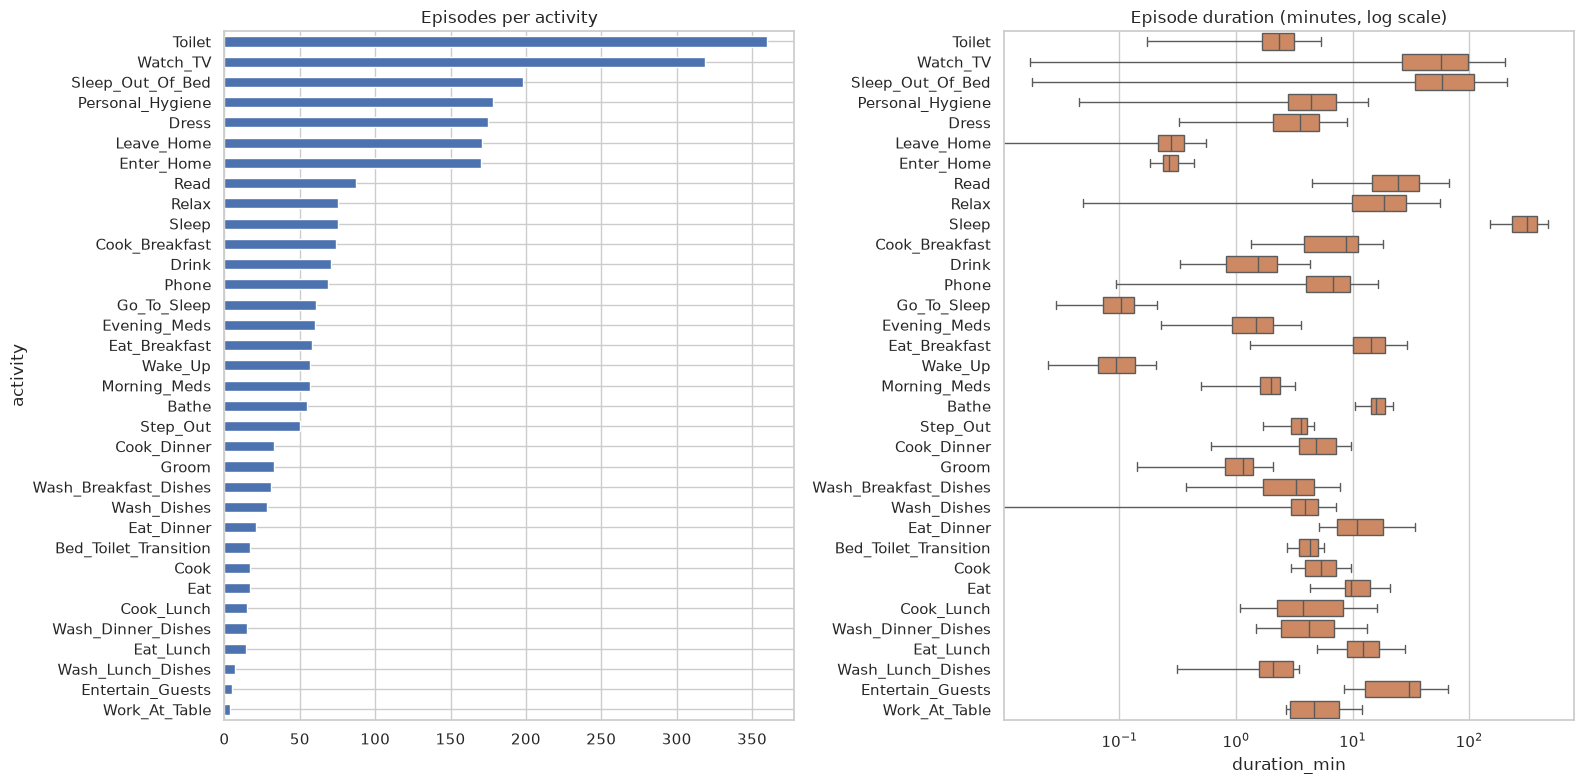

In [15]:
order = stats.sort_values("episodes", ascending=False).index
fig, ax = plt.subplots(1, 2, figsize=(16, 8))
stats.loc[order[::-1], "episodes"].plot.barh(ax=ax[0], color="C0", title="Episodes per activity")
sns.boxplot(data=ep, y="activity", x="duration_min", order=order, showfliers=False, ax=ax[1], color="C1")
ax[1].set_xscale("log"); ax[1].set_title("Episode duration (minutes, log scale)"); ax[1].set_ylabel("")
plt.tight_layout(); plt.savefig(FIG / "eda_activities.png", dpi=110); plt.show()

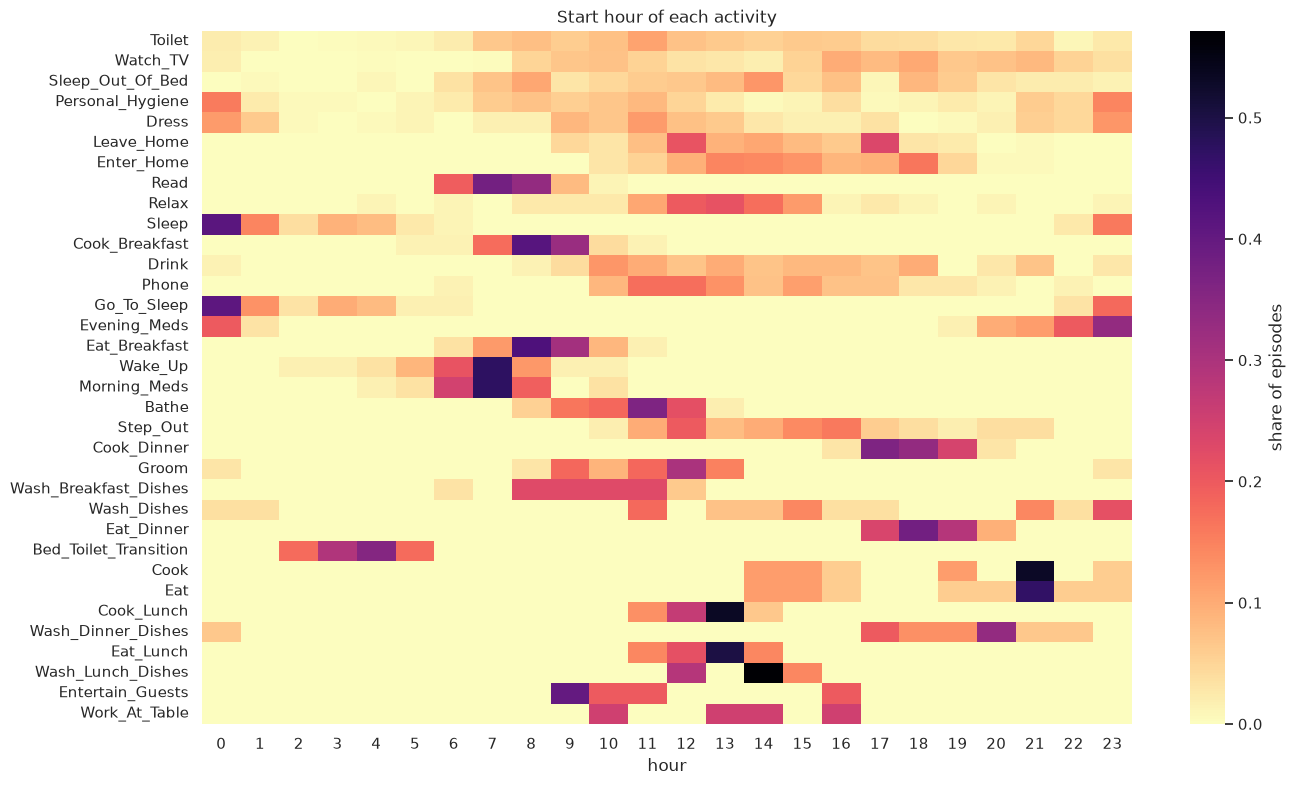

In [16]:
prof = pd.crosstab(ep.activity, ep.start.dt.hour).reindex(index=order, columns=range(24), fill_value=0)
plt.figure(figsize=(15, 9))
sns.heatmap(prof.div(prof.sum(axis=1), axis=0), cmap="magma_r", cbar_kws={"label": "share of episodes"})
plt.title("Start hour of each activity"); plt.xlabel("hour"); plt.ylabel("")
plt.savefig(FIG / "eda_activity_hour.png", dpi=110, bbox_inches="tight"); plt.show()

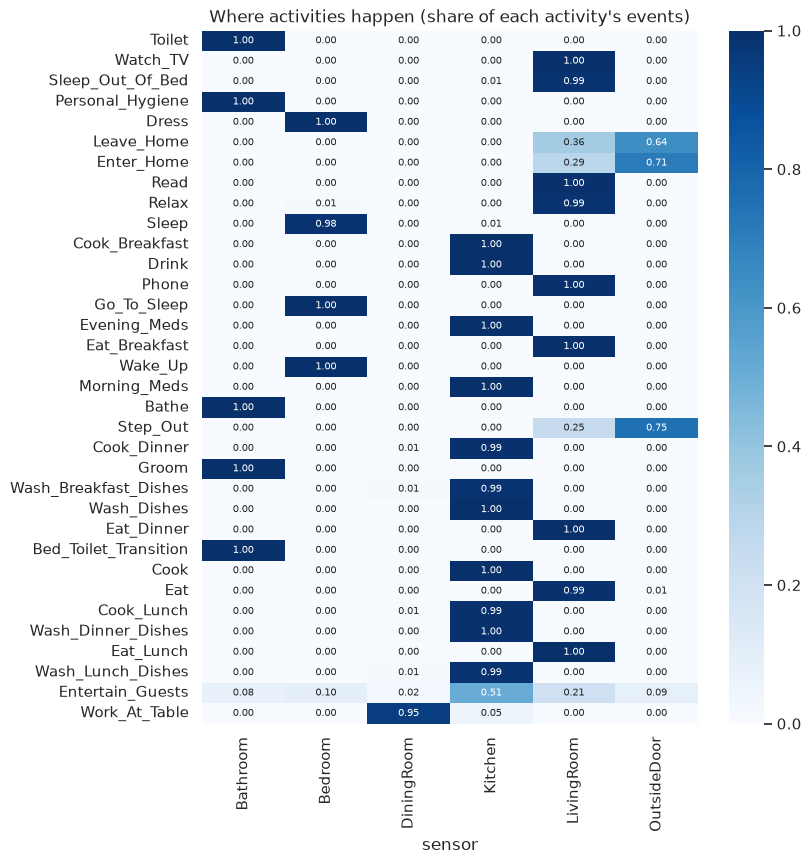

In [17]:
ar = pd.crosstab(lab.activity, lab.sensor, normalize="index").reindex(order)
plt.figure(figsize=(8, 9))
sns.heatmap(ar, cmap="Blues", annot=True, fmt=".2f", annot_kws={"size": 7})
plt.title("Where activities happen (share of each activity's events)"); plt.ylabel(""); plt.show()

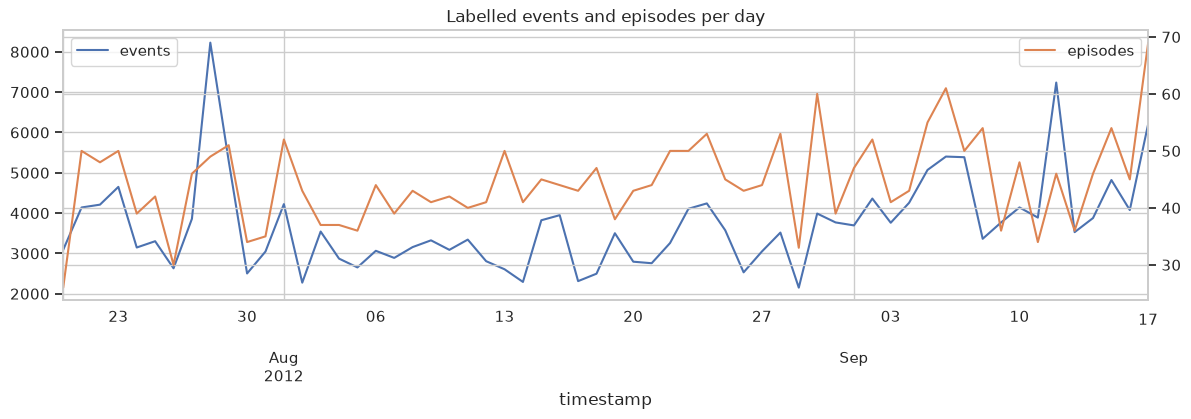

In [18]:
lab_days = lab.set_index("timestamp").resample("D").size()
ep_days = ep.set_index("start").resample("D").size()
fig, ax = plt.subplots(figsize=(14, 3.5))
lab_days.plot(ax=ax, label="events"); ax2 = ax.twinx()
ep_days.plot(ax=ax2, color="C1", label="episodes")
ax.set_title("Labelled events and episodes per day"); ax.legend(loc="upper left"); ax2.legend(loc="upper right")
plt.show()

## 6. Activity transitions

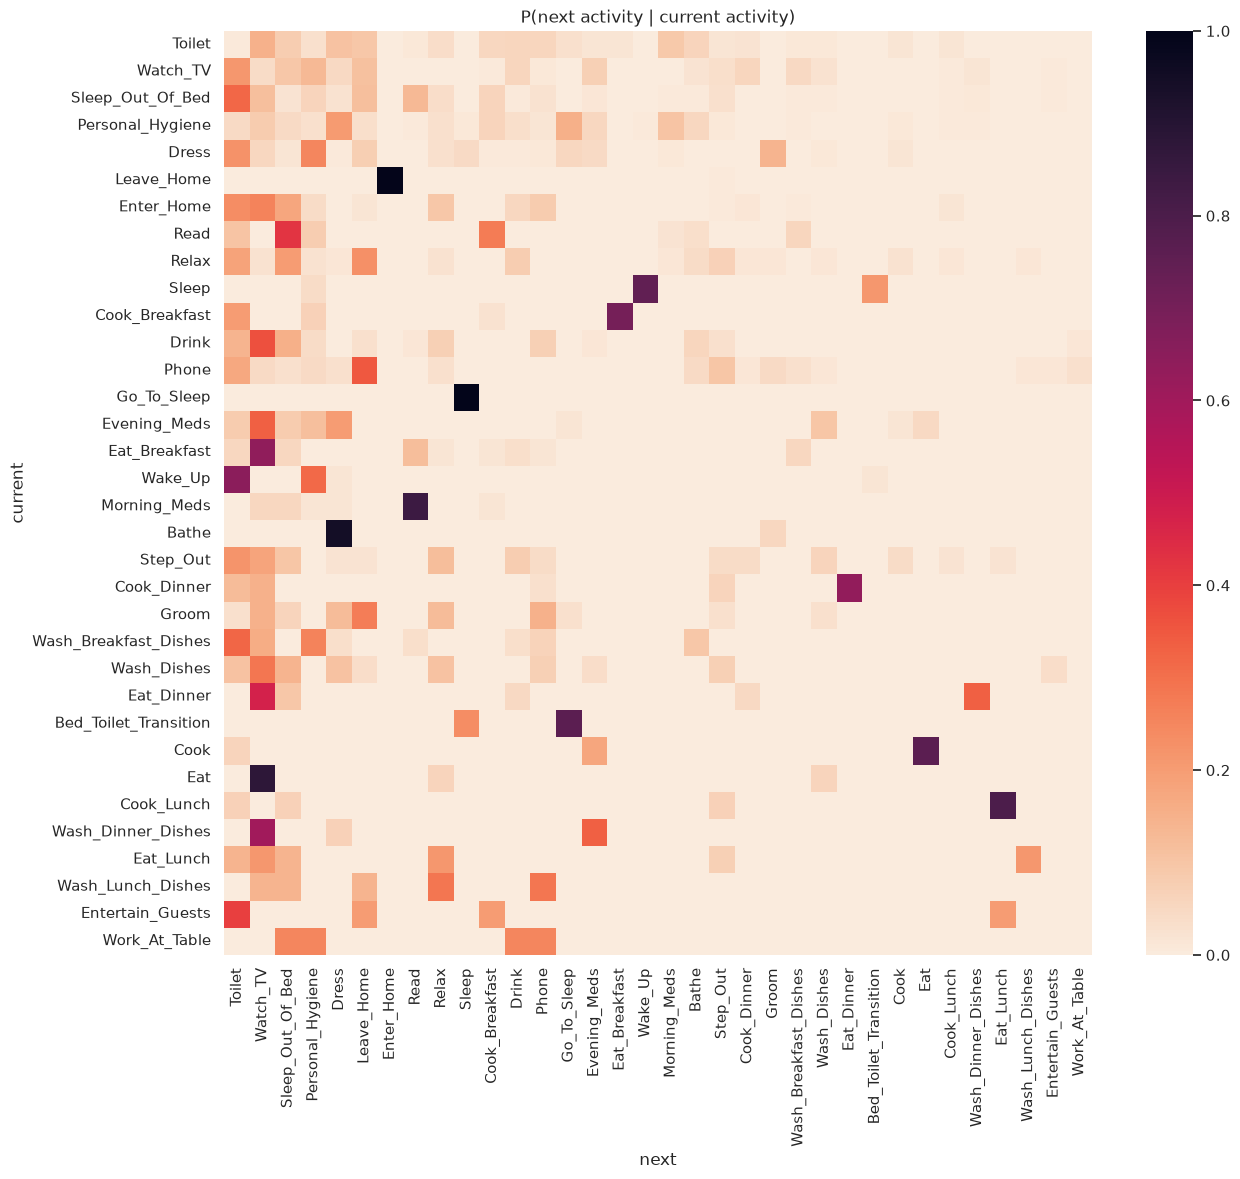

,most likely next,p
activity,,
Go_To_Sleep,Sleep,1.00
Leave_Home,Enter_Home,0.99
Bathe,Dress,0.95
Eat,Watch_TV,0.88
Morning_Meds,Read,0.84
Cook_Lunch,Eat_Lunch,0.80
Bed_Toilet_Transition,Go_To_Sleep,0.76
Cook,Eat,0.76
Sleep,Wake_Up,0.75


In [19]:
nxt = ep.activity.shift(-1)
trans = pd.crosstab(ep.activity, nxt, normalize="index").reindex(index=order, columns=order, fill_value=0)
plt.figure(figsize=(14, 12))
sns.heatmap(trans, cmap="rocket_r")
plt.title("P(next activity | current activity)"); plt.xlabel("next"); plt.ylabel("current")
plt.savefig(FIG / "eda_transitions.png", dpi=110, bbox_inches="tight"); plt.show()
best = pd.DataFrame({"most likely next": trans.idxmax(axis=1), "p": trans.max(axis=1)}).sort_values("p", ascending=False)
best.round(2).head(15)

In [20]:
def cond_entropy(x, y):
    p = pd.crosstab(x, y).values.astype(float); p /= p.sum()
    pc = p / p.sum(axis=1, keepdims=True)
    return float(-(p[p > 0] * np.log2(pc[p > 0])).sum())

e = ep.assign(next=nxt).dropna(subset=["next"])
H = {
    "H(next)": cond_entropy(np.zeros(len(e)), e.next),
    "H(next | current)": cond_entropy(e.activity, e.next),
    "H(next | current, 3h bin)": cond_entropy(e.activity + "@" + (e.end.dt.hour // 3).astype(str), e.next),
    "H(next | previous, current)": cond_entropy(e.activity.shift().fillna("") + ">" + e.activity, e.next),
}
pd.Series(H, name="bits").round(3)

H(next)                        4.420
H(next | current)              2.643
H(next | current, 3h bin)      2.021
H(next | previous, current)    1.788
Name: bits, dtype: float64

## 7. Summary

In [21]:
pd.Series({
    "raw events": f"{len(raw):,}",
    "raw period": f"{raw.timestamp.min():%Y-%m-%d} to {raw.timestamp.max():%Y-%m-%d}",
    "labelled events": f"{len(lab):,}",
    "labelled period": f"{lab.timestamp.min():%Y-%m-%d} to {lab.timestamp.max():%Y-%m-%d}",
    "sensors (rooms)": raw.sensor.nunique(),
    "activity labels": lab.activity.nunique() - 1,
    "events labelled Other": f"{(lab.activity == 'Other').mean():.1%}",
    "activity episodes": len(ep),
    "median inter-event time (s)": round(dt.median(), 2),
}, name="value").to_frame()

,value
raw events,"1,286,244"
raw period,2012-07-18 to 2013-07-25
labelled events,"222,858"
labelled period,2012-07-20 to 2012-09-17
sensors (rooms),6
activity labels,34
events labelled Other,27.9%
activity episodes,2677
median inter-event time (s),1.17


### Key findings
1. **Scale and quality.** The raw stream has 1.29M events over one year (2012-07-18 to 2013-07-25), about
   3,500 events per day. It has no missing values and no duplicate rows. The only outage is a two-day gap
   in early July 2013. The labelled subset covers 59 days (222,858 events) and has one out-of-order
   timestamp, which the loader fixes by sorting.
2. **Sensors.** There are six room-level sensors. Motion `ON/OFF` makes up 99.4% of events, and
   `OPEN/CLOSE` comes almost only from the outside door. Most traffic is in the living room (33%), bedroom
   (23%) and kitchen (22%). A typical motion trigger lasts about 1–2 s.
3. **Temporal structure.** There is a clear circadian rhythm: activity peaks between 09:00 and 12:00, and
   only 8.6% of events fall between 00:00 and 06:00. Kitchen activity peaks at 08–10h (breakfast), and
   bedroom activity at 23–00h. Weekends have about 10% more events than weekdays. Inter-event times are
   heavy-tailed (median 1.2 s, 99th percentile 341 s): the stream is bursty.
4. **Labels.** There are 34 activity labels, and 27.9% of labelled-file events fall outside any annotated
   activity (`Other`). The labels are strongly imbalanced: *Toilet*, *Watch_TV*, *Sleep_Out_Of_Bed*,
   *Personal_Hygiene* and *Dress* account for over 45% of the 2,677 episodes, while 9 labels have fewer
   than 20 episodes. Durations range from seconds (*Wake_Up*, *Go_To_Sleep*) to about 5 hours (*Sleep*).
5. **Activities have strong time and room signatures.** For example, *Wake_Up* / *Morning_Meds* happen at
   06–08h, *Cook_Breakfast* / *Eat_Breakfast* at 07–09h, *Cook_Dinner* / *Eat_Dinner* at 17–19h,
   *Evening_Meds* at 21–23h, and *Bed_Toilet_Transition* at 02–05h.
6. **Sequential structure.** Many transitions are almost deterministic (*Go_To_Sleep → Sleep* 1.00,
   *Leave_Home → Enter_Home* 0.99, *Bathe → Dress* 0.95, *Cook → Eat*). Knowing the current activity
   reduces the entropy of the next activity from 4.42 to 2.64 bits. Adding the time of day (2.02) or the
   previous activity (1.79) reduces it further. This motivates a model that uses both the activity
   history and time features (Task 2).